In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score



In [2]:
amazon  = pd.read_csv('Amazon.csv', encoding='latin-1')
google  = pd.read_csv('GoogleProducts.csv', encoding='latin-1')
mapping = pd.read_csv('Amzon_GoogleProducts_perfectMapping.csv', encoding='latin-1')

In [3]:
print('amazon shape:', amazon.shape)
print('google shape:', google.shape)
print('mapping shape:', mapping.shape)

print('\namazon columns:', amazon.columns.tolist())
print('google columns:', google.columns.tolist())
print('mapping columns:', mapping.columns.tolist())

print('\namazon sample:')
print(amazon.head(3))

print('\ngoogle sample:')
print(google.head(3))

print('\nmapping sample:')
print(mapping.head(3))

amazon shape: (1363, 5)
google shape: (3226, 5)
mapping shape: (1300, 2)

amazon columns: ['id', 'title', 'description', 'manufacturer', 'price']
google columns: ['id', 'name', 'description', 'manufacturer', 'price']
mapping columns: ['idAmazon', 'idGoogleBase']

amazon sample:
           id                                             title  \
0  b000jz4hqo   clickart 950 000 - premier image pack (dvd-rom)   
1  b0006zf55o  ca international - arcserve lap/desktop oem 30pk   
2  b00004tkvy  noah's ark activity center (jewel case ages 3-8)   

                                         description         manufacturer  \
0                                                NaN           broderbund   
1  oem arcserve backup v11.1 win 30u for laptops ...  computer associates   
2                                                NaN   victory multimedia   

   price  
0    0.0  
1    0.0  
2    0.0  

google sample:
                                                  id  \
0  http://www.google.com/ba

In [4]:
print('=== Null Counts ===')
print('\namazon nulls:')
print(amazon.isnull().sum())

print('\ngoogle nulls:')
print(google.isnull().sum())

print('\n=== Price Issues ===')
print('amazon price = 0:', (amazon['price'] == 0).sum())
print('google price = 0:', (google['price'] == 0).sum())

=== Null Counts ===

amazon nulls:
id                0
title             0
description     115
manufacturer      0
price             0
dtype: int64

google nulls:
id                 0
name               0
description      191
manufacturer    2994
price              0
dtype: int64

=== Price Issues ===
amazon price = 0: 199
google price = 0: 0


In [5]:
# saving before cleaning for comparison
amazon_before = amazon[['title', 'manufacturer', 'price']].head(3).copy()
google_before = google[['name', 'manufacturer', 'price']].head(3).copy()


In [6]:
# clean amazon
amazon['title']        = amazon['title'].fillna('').str.lower().str.strip()
amazon['description']  = amazon['description'].fillna('').str.lower().str.strip()
amazon['manufacturer'] = amazon['manufacturer'].fillna('').str.lower().str.strip()
amazon['price']        = pd.to_numeric(amazon['price'], errors='coerce')
amazon['price']        = amazon['price'].where(amazon['price'] > 0, np.nan)

In [7]:
# clean google
google['name']         = google['name'].fillna('').str.lower().str.strip()
google['description']  = google['description'].fillna('').str.lower().str.strip()
google['manufacturer'] = google['manufacturer'].fillna('').str.lower().str.strip()
google['price']        = pd.to_numeric(google['price'], errors='coerce')
google['price']        = google['price'].where(google['price'] > 0, np.nan)

In [8]:
# combined text field
amazon['text'] = amazon['title'] + ' ' + amazon['manufacturer'] + ' ' + amazon['description']
google['text'] = google['name']  + ' ' + google['manufacturer'] + ' ' + google['description']

In [9]:
# print before and after
print('=== AMAZON BEFORE ===')
print(amazon_before)
print('\n=== AMAZON AFTER ===')
print(amazon[['title', 'manufacturer', 'price']].head(3))

=== AMAZON BEFORE ===
                                              title         manufacturer  \
0   clickart 950 000 - premier image pack (dvd-rom)           broderbund   
1  ca international - arcserve lap/desktop oem 30pk  computer associates   
2  noah's ark activity center (jewel case ages 3-8)   victory multimedia   

   price  
0    0.0  
1    0.0  
2    0.0  

=== AMAZON AFTER ===
                                              title         manufacturer  \
0   clickart 950 000 - premier image pack (dvd-rom)           broderbund   
1  ca international - arcserve lap/desktop oem 30pk  computer associates   
2  noah's ark activity center (jewel case ages 3-8)   victory multimedia   

   price  
0    NaN  
1    NaN  
2    NaN  


In [10]:
print('\n=== GOOGLE BEFORE ===')
print(google_before)
print('\n=== GOOGLE AFTER ===')
print(google[['name', 'manufacturer', 'price']].head(3))


=== GOOGLE BEFORE ===
                                      name manufacturer   price
0                 learning quickbooks 2007       intuit   38.99
1  superstart! fun with reading & writing!          NaN    8.49
2                qb pos 6.0 basic software       intuit  637.99

=== GOOGLE AFTER ===
                                      name manufacturer   price
0                 learning quickbooks 2007       intuit   38.99
1  superstart! fun with reading & writing!                 8.49
2                qb pos 6.0 basic software       intuit  637.99


In [11]:
# build tfidf on all titles first
tfidf = TfidfVectorizer(ngram_range=(1, 2))
tfidf.fit(pd.concat([amazon['title'], google['name']], ignore_index=True))

amazon_vecs = tfidf.transform(amazon['title'])
google_vecs = tfidf.transform(google['name'])

# index lookups
amazon_row = dict(zip(amazon['id'], range(len(amazon))))
google_row = dict(zip(google['id'], range(len(google))))

candidates = []

for _, amz in amazon.iterrows():
    a_i = amazon_row.get(amz['id'])

    # signal 1 — same manufacturer blocking
    if amz['manufacturer'] != '':
        google_same_mfr = google[google['manufacturer'] == amz['manufacturer']]
    else:
        google_same_mfr = pd.DataFrame()

    # signal 2 — keyword overlap blocking
    amz_words = set(amz['title'].split())
    keyword_mask = google['name'].apply(
        lambda g: len(amz_words & set(g.split())) >= 2
    )
    google_keyword = google[keyword_mask]

    # combine both and remove duplicates
    google_candidates = pd.concat([google_same_mfr, google_keyword]).drop_duplicates(subset='id')

    for _, ggl in google_candidates.iterrows():
        candidates.append({
            'amazon_id'  : amz['id'],
            'google_id'  : ggl['id'],
            'amazon_name': amz['title'],
            'google_name': ggl['name'],
        })

candidates = pd.DataFrame(candidates).drop_duplicates(subset=['amazon_id', 'google_id']).reset_index(drop=True)

print('total candidate pairs:', len(candidates))
print('\nsample:')
print(candidates.head(5))

total candidate pairs: 64380

sample:
    amazon_id                                          google_id  \
0  b000jz4hqo  http://www.google.com/base/feeds/snippets/1349...   
1  b000jz4hqo  http://www.google.com/base/feeds/snippets/1346...   
2  b000jz4hqo  http://www.google.com/base/feeds/snippets/1345...   
3  b000jz4hqo  http://www.google.com/base/feeds/snippets/1348...   
4  b000jz4hqo  http://www.google.com/base/feeds/snippets/1369...   

                                       amazon_name  \
0  clickart 950 000 - premier image pack (dvd-rom)   
1  clickart 950 000 - premier image pack (dvd-rom)   
2  clickart 950 000 - premier image pack (dvd-rom)   
3  clickart 950 000 - premier image pack (dvd-rom)   
4  clickart 950 000 - premier image pack (dvd-rom)   

                                         google_name  
0  633808390266 wasp mobileasset professional edi...  
1  711-00072 microsoft entertainment pocketpak 20...  
2  c6q-00002 microsoft digital image suite plus -...  
3  36612

In [12]:
amazon_price = dict(zip(amazon['id'], amazon['price']))
google_price = dict(zip(google['id'], google['price']))
amazon_mfr   = dict(zip(amazon['id'], amazon['manufacturer']))
google_mfr   = dict(zip(google['id'], google['manufacturer']))

amazon_vecs2 = tfidf.transform(amazon['title'])
google_vecs2 = tfidf.transform(google['name'])

scores = []
for _, row in candidates.iterrows():
    a_i = amazon_row.get(row['amazon_id'])
    g_i = google_row.get(row['google_id'])

    # title similarity
    title_sim = cosine_similarity(amazon_vecs2[a_i], google_vecs2[g_i])[0][0]

    # manufacturer match
    a_mfr = amazon_mfr.get(row['amazon_id'], '')
    g_mfr = google_mfr.get(row['google_id'], '')
    mfr_match = 1.0 if (a_mfr != '' and g_mfr != '' and a_mfr == g_mfr) else 0.0

    # price similarity
    a_price = amazon_price.get(row['amazon_id'])
    g_price = google_price.get(row['google_id'])
    if pd.notna(a_price) and pd.notna(g_price) and a_price > 0 and g_price > 0:
        price_sim = 1 - abs(a_price - g_price) / max(a_price, g_price)
        price_sim = max(0, price_sim)
    else:
        price_sim = 0.5

    # final combined score
    final_score = (0.8 * title_sim) + (0.2 * price_sim)

    scores.append({
        'amazon_id'  : row['amazon_id'],
        'google_id'  : row['google_id'],
        'amazon_name': row['amazon_name'],
        'google_name': row['google_name'],
        'title_sim'  : round(title_sim, 4),
        'mfr_match'  : mfr_match,
        'price_sim'  : round(price_sim, 4),
        'final_score': round(final_score, 4),
    })

scores_df = pd.DataFrame(scores)
print('scored pairs:', len(scores_df))
print('\ntop 10 matches:')
print(scores_df.sort_values('final_score', ascending=False).head(10)[['amazon_name', 'google_name', 'title_sim', 'mfr_match', 'price_sim', 'final_score']])

scored pairs: 64380

top 10 matches:
                                     amazon_name  \
49980   iaudioize - magnetic time for pc and mac   
39871                adobe illustrator cs3 [mac]   
51109      norton internet security 2008 10 user   
39504  agatha christie: and then there were none   
2409                 kaplan sat/act/psat express   
57190           print explosion deluxe 3.0 (mac)   
15504                 photo explosion deluxe 3.0   
46405                      hoyle card games 2007   
22400          zonealarm internet security suite   
29224               quickbooks simple start 2007   

                                     google_name  title_sim  mfr_match  \
49980     iaudioize magnetic time for pc and mac        1.0        0.0   
39871                adobe illustrator cs3 (mac)        1.0        0.0   
51109      norton internet security 2008 10 user        1.0        0.0   
39504  agatha christie: and then there were none        1.0        0.0   
2409                

In [13]:
# pick best google match per amazon product (one-to-one)
best_matches = (
    scores_df
    .sort_values('final_score', ascending=False)
    .drop_duplicates(subset='amazon_id', keep='first')
    .drop_duplicates(subset='google_id', keep='first')
    .reset_index(drop=True)
)

# confidence assignment
def assign_confidence(score):
    if score >= 0.65:
        return 'HIGH'
    elif score >= 0.5:
        return 'MEDIUM'
    elif score >= 0.3:
        return 'LOW'
    else:
        return 'NONE'

best_matches['confidence'] = best_matches['final_score'].apply(assign_confidence)

print('total matched amazon products:', len(best_matches))
print('\nconfidence distribution:')
print(best_matches['confidence'].value_counts())

print('\ntop 10 matches:')
print(best_matches[['amazon_name', 'google_name', 'final_score', 'confidence']].head(10))

total matched amazon products: 1114

confidence distribution:
confidence
HIGH      611
MEDIUM    264
LOW       199
NONE       40
Name: count, dtype: int64

top 10 matches:
                                 amazon_name  \
0   iaudioize - magnetic time for pc and mac   
1                adobe illustrator cs3 [mac]   
2      norton internet security 2008 10 user   
3  agatha christie: and then there were none   
4                kaplan sat/act/psat express   
5           print explosion deluxe 3.0 (mac)   
6                 photo explosion deluxe 3.0   
7                      hoyle card games 2007   
8          zonealarm internet security suite   
9               quickbooks simple start 2007   

                                 google_name  final_score confidence  
0     iaudioize magnetic time for pc and mac       1.0000       HIGH  
1                adobe illustrator cs3 (mac)       1.0000       HIGH  
2      norton internet security 2008 10 user       1.0000       HIGH  
3  agatha chris

In [14]:
# prepare ground truth
ground_truth = set(zip(mapping['idAmazon'], mapping['idGoogleBase']))

# prepare our predictions — only keep matches above threshold
THRESHOLD = 0.3
predictions = best_matches[best_matches['final_score'] >= THRESHOLD]
predicted   = set(zip(predictions['amazon_id'], predictions['google_id']))

# calculate true positives, false positives, false negatives
tp = len(predicted & ground_truth)
fp = len(predicted - ground_truth)
fn = len(ground_truth - predicted)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=== Evaluation Results ===')
print(f'True Positives  : {tp}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}')
print(f'Precision       : {round(precision, 4)}')
print(f'Recall          : {round(recall, 4)}')
print(f'F1 Score        : {round(f1, 4)}')

print('\n=== What this means ===')
print(f'Out of {len(predicted)} matches we predicted, {tp} were correct')
print(f'We missed {fn} true matches out of {len(ground_truth)} total')

=== Evaluation Results ===
True Positives  : 743
False Positives : 331
False Negatives : 557
Precision       : 0.6918
Recall          : 0.5715
F1 Score        : 0.6259

=== What this means ===
Out of 1074 matches we predicted, 743 were correct
We missed 557 true matches out of 1300 total


In [15]:
def find_matches(title, manufacturer='', price=None, top_n=3):

    # clean input
    title        = title.lower().strip()
    manufacturer = manufacturer.lower().strip()

    # convert input to tfidf vector
    input_vec = tfidf.transform([title])

    # score against all google products
    results = []
    for _, ggl in google.iterrows():
        g_i = google_row.get(ggl['id'])

        # title similarity
        title_sim = cosine_similarity(input_vec, google_vecs2[g_i])[0][0]

        # manufacturer match
        g_mfr     = ggl['manufacturer']
        mfr_match = 1.0 if (manufacturer != '' and g_mfr != '' and manufacturer == g_mfr) else 0.0

        # price similarity
        g_price = ggl['price']
        if price is not None and pd.notna(g_price) and price > 0 and g_price > 0:
            price_sim = 1 - abs(price - g_price) / max(price, g_price)
            price_sim = max(0, price_sim)
        else:
            price_sim = 0.5

        # final score
        final_score = (0.8 * title_sim) + (0.2 * price_sim)

        results.append({
            'google_name' : ggl['name'],
            'title_sim'   : round(title_sim, 4),
            'mfr_match'   : mfr_match,
            'price_sim'   : round(price_sim, 4),
            'final_score' : round(final_score, 4),
        })

    # sort and get top N
    results_df = pd.DataFrame(results).sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)

    # assign confidence
    def assign_confidence(score):
        if score >= 0.65:   return 'HIGH'
        elif score >= 0.5: return 'MEDIUM'
        elif score >= 0.3: return 'LOW'
        else:              return 'NONE'

    # print results
    print(f'\n=== Top {top_n} Matches for: "{title}" ===\n')
    for i, row in results_df.iterrows():
        conf = assign_confidence(row['final_score'])
        print(f'Match {i+1}')
        print(f'  Google Product : {row["google_name"]}')
        print(f'  Final Score    : {row["final_score"]}')
        print(f'  Confidence     : {conf}')
        print(f'  Score Breakdown:')
        print(f'    Title Sim    : {row["title_sim"]}')
        print(f'    Brand Match  : {row["mfr_match"]}')
        print(f'    Price Sim    : {row["price_sim"]}')
        if conf == 'NONE':
            print(f'  Result         : NO_MATCH — score too low')
        print()

    return results_df

# test it
find_matches(
    title        = 'quicken 2007 deluxe',
    manufacturer = 'intuit',
    price        = 35.0
)


=== Top 3 Matches for: "quicken 2007 deluxe" ===

Match 1
  Google Product : quicken 2007 deluxe win cd
  Final Score    : 0.7094
  Confidence     : HIGH
  Score Breakdown:
    Title Sim    : 0.7358
    Brand Match  : 1.0
    Price Sim    : 0.6036

Match 2
  Google Product : microsoft(r) money 2007 deluxe
  Final Score    : 0.4985
  Confidence     : LOW
  Score Breakdown:
    Title Sim    : 0.4481
    Brand Match  : 0.0
    Price Sim    : 0.7001

Match 3
  Google Product : intuit quicken 2007 macintosh
  Final Score    : 0.4395
  Confidence     : LOW
  Score Breakdown:
    Title Sim    : 0.4244
    Brand Match  : 0.0
    Price Sim    : 0.5001



,google_name,title_sim,mfr_match,price_sim,final_score
0,quicken 2007 deluxe win cd,0.7358,1.0,0.6036,0.7094
1,microsoft(r) money 2007 deluxe,0.4481,0.0,0.7001,0.4985
2,intuit quicken 2007 macintosh,0.4244,0.0,0.5001,0.4395


In [16]:
print('=== TESTING STRATEGY ===')
print()

# test 1 — perfect match
print('TEST 1 — Perfect title match')
find_matches(title='learning quickbooks 2007', manufacturer='intuit', price=38.99)

# test 2 — missing manufacturer
print('TEST 2 — Missing manufacturer')
find_matches(title='adobe illustrator cs3', manufacturer='', price=None)

# test 3 — zero price / missing price
print('TEST 3 — No price provided')
find_matches(title='norton antivirus 2007', manufacturer='symantec', price=None)

# test 4 — unrelated product (should return NO_MATCH or LOW)
print('TEST 4 — Unrelated product (should be low confidence)')
find_matches(title='random kitchen blender xyz', manufacturer='', price=None)

# test 5 — partial title
print('TEST 5 — Partial title only')
find_matches(title='quickbooks', manufacturer='', price=None)

=== TESTING STRATEGY ===

TEST 1 — Perfect title match

=== Top 3 Matches for: "learning quickbooks 2007" ===

Match 1
  Google Product : learning quickbooks 2007
  Final Score    : 1.0
  Confidence     : HIGH
  Score Breakdown:
    Title Sim    : 1.0
    Brand Match  : 1.0
    Price Sim    : 1.0

Match 2
  Google Product : learning quickbooks(r) for windows(r)
  Final Score    : 0.627
  Confidence     : MEDIUM
  Score Breakdown:
    Title Sim    : 0.54
    Brand Match  : 0.0
    Price Sim    : 0.975

Match 3
  Google Product : learning quickbooks (pc) intuit
  Final Score    : 0.5717
  Confidence     : MEDIUM
  Score Breakdown:
    Title Sim    : 0.4708
    Brand Match  : 0.0
    Price Sim    : 0.975

TEST 2 — Missing manufacturer

=== Top 3 Matches for: "adobe illustrator cs3" ===

Match 1
  Google Product : adobe illustrator cs3 (mac)
  Final Score    : 0.8044
  Confidence     : HIGH
  Score Breakdown:
    Title Sim    : 0.8805
    Brand Match  : 0.0
    Price Sim    : 0.5

Match 2


,google_name,title_sim,mfr_match,price_sim,final_score
0,quickbooks(r),1.0,0.0,0.5,0.9
1,quickbooks(r),1.0,0.0,0.5,0.9
2,quickbooks(r),1.0,0.0,0.5,0.9


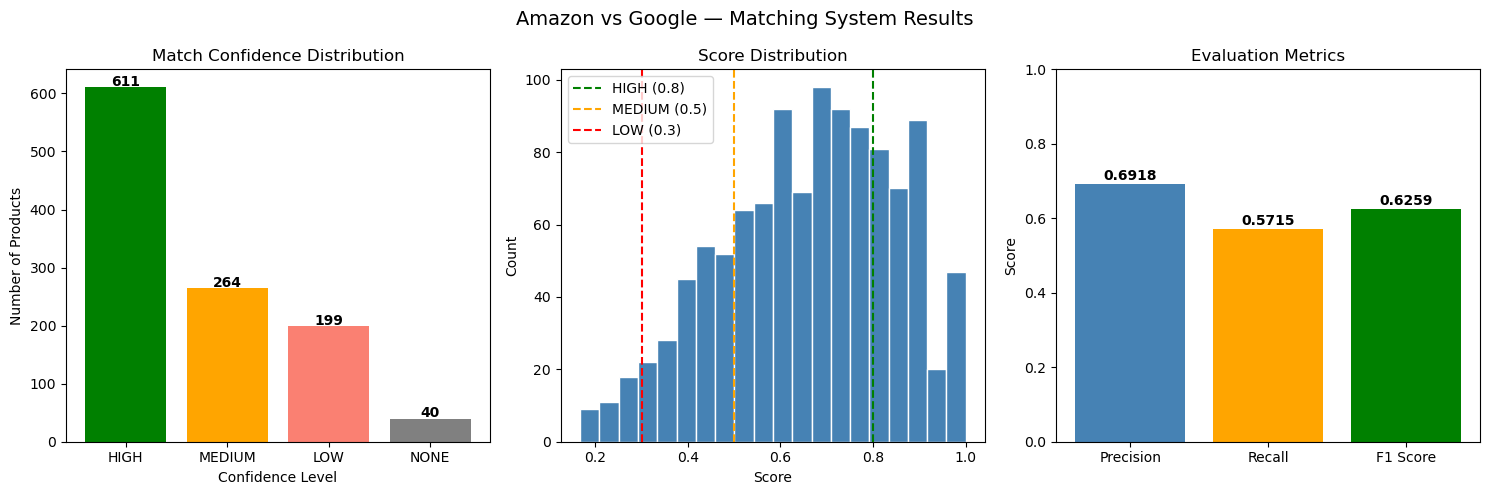

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# graph 1 — confidence distribution
confidence_counts = best_matches['confidence'].value_counts()
colors = ['green', 'orange', 'salmon', 'grey']
axes[0].bar(confidence_counts.index, confidence_counts.values, color=colors)
axes[0].set_title('Match Confidence Distribution')
axes[0].set_xlabel('Confidence Level')
axes[0].set_ylabel('Number of Products')
for i, v in enumerate(confidence_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# graph 2 — score distribution
axes[1].hist(best_matches['final_score'], bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(x=0.8, color='green',  linestyle='--', label='HIGH (0.8)')
axes[1].axvline(x=0.5, color='orange', linestyle='--', label='MEDIUM (0.5)')
axes[1].axvline(x=0.3, color='red',    linestyle='--', label='LOW (0.3)')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].legend()

# graph 3 — evaluation results
metrics = ['Precision', 'Recall', 'F1 Score']
values  = [precision, recall, f1]
colors3 = ['steelblue', 'orange', 'green']
axes[2].bar(metrics, values, color=colors3)
axes[2].set_title('Evaluation Metrics')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score')
for i, v in enumerate(values):
    axes[2].text(i, v + 0.01, str(round(v, 4)), ha='center', fontweight='bold')

plt.suptitle('Amazon vs Google — Matching System Results', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
best_matches.to_csv('matching_output.csv', index=False)
print('saved!')

saved!


In [19]:
true_match_scores = scores_df.merge(
    mapping.rename(columns={'idAmazon': 'amazon_id', 'idGoogleBase': 'google_id'}),
    on=['amazon_id', 'google_id'],
    how='inner'
)
true_match_scores['confidence'] = true_match_scores['final_score'].apply(assign_confidence)
print('=== Where true matches are scoring now ===')
print(true_match_scores['confidence'].value_counts())

=== Where true matches are scoring now ===
confidence
HIGH      564
MEDIUM    333
LOW       259
NONE       54
Name: count, dtype: int64


In [20]:
print("--- SIMILARITY CHECKER ---")
print("Type 'quit' to exit\n")

while True:
    print("-" * 40)
    title        = input("Enter product title      : ")
    
    if title.lower() == 'quit':
        print("Exiting similarity checker.")
        break
    
    manufacturer = input("Enter manufacturer (or press Enter to skip) : ")
    price_input  = input("Enter price (or press Enter to skip)        : ")
    
    price = float(price_input) if price_input.strip() != '' else None
    
    find_matches(title=title, manufacturer=manufacturer, price=price)
    
    print()

--- SIMILARITY CHECKER ---
Type 'quit' to exit

----------------------------------------


Enter product title      :  quit


Exiting similarity checker.


In [21]:
import pickle

model_data = {
    'amazon'      : amazon,
    'google'      : google,
    'tfidf'       : tfidf,
    'amazon_vecs2': amazon_vecs2,
    'google_vecs2': google_vecs2,
    'amazon_row'  : amazon_row,
    'google_row'  : google_row,
}

with open('model_data.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('saved!')

saved!
